<a href="https://colab.research.google.com/github/christoforou/CUS_graduate_courses/blob/master/CUS752/Materials/01_LinearAlgebraReview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Algebra Review

In Machine Learning, models often operate on data represented as vectors or tensors. To work effectively with these structures, we need to manipulate them and perform fundamental mathematical operations—many of which come directly from linear algebra. This section provides a concise introduction to the essential linear algebra concepts that frequently arise in Machine Learning, beginning with basic vector and scalar operations and building up to matrix multiplication.


In [ ]:
# will be using torch to illustrate examples of linear algebra operations.
import torch

## Scalars

Most everyday mathematics consists of manipulating
numbers one at a time. Formally, we call these values *scalars*. For example, the temperature in Palo Alto is a balmy $72$ degrees Fahrenheit.
If you wanted to convert the temperature to Celsius you would evaluate the expression
$c = \frac{5}{9}(f - 32)$, setting $f$ to $72$.
In this equation, the values
$5$, $9$, and $32$ are constant scalars.
The variables $c$ and $f$ in general represent unknown scalars.

We denote scalars by ordinary lower-cased letters
(e.g., $x$, $y$, and $z$) and the space of all (continuous)
*real-valued* scalars by $\mathbb{R}$. For expedience, we will skip past
rigorous definitions of *spaces*: just remember that the expression $x \in \mathbb{R}$ is a formal way to say that $x$ is a real-valued scalar.

The symbol $\in$ (pronounced "in") denotes membership in a set.
For example, $x, y \in \{0, 1\}$ indicates that $x$ and $y$ are variables that can only take values $0$ or $1$.

(**Scalars are implemented as tensors that contain only one element.**)
Below, we assign two scalars and perform the familiar addition, multiplication, division, and exponentiation operations.


In [ ]:
# Define variables x and y, as scalar values in pytorch.
x = torch.tensor(3.0)
y = torch.tensor(2.0)

# use the variables to perform basic arithmetic operations (add, multiply, divide, exponentiate)
x + y, x * y, x / y, x**y

(tensor(5.), tensor(6.), tensor(1.5000), tensor(9.))

## Vectors

From a programmers point of you, we can think of a vector as a fixed-length 1D array of scalars. As with their code counterparts, we call these scalars the *elements* of the vector (synonyms include *entries* and *components*).

In machine learning datasets, data observations are often represented as  vectors, and their values hold some real-world significance. For example, if we were training a model to predict the risk of a loan defaulting, we might associate each applicant with a vector whose components correspond to quantities like their income, length of employment, or number of previous defaults.

If we were studying the risk of heart attack, each vector might represent a patient and its components might correspond to their most recent vital signs, cholesterol levels,  minutes of exercise per day, etc.

We denote vectors by bold lowercase letters,  (e.g., $\mathbf{x}$, $\mathbf{y}$, and $\mathbf{z}$).

Vectors are implemented as $1^{\textrm{st}}$-order tensors. In general, such tensors can have arbitrary lengths, subject to memory limitations.

Caution: in Python, as in most programming languages, vector indices start at $0$, also known as *zero-based indexing*, whereas in linear algebra subscripts begin at $1$ (one-based indexing).


In [ ]:
# An example of a vector with three element, with values  [0,1,2]
x = torch.arange(3)
x

tensor([0, 1, 2])

We can refer to an element of a vector by using a subscript.
For example, $x_2$ denotes the second element of $\mathbf{x}$.
Since $x_2$ is a scalar, we do not bold it.
By default, we visualize vectors
by stacking their elements vertically.

$$\mathbf{x} =\begin{bmatrix}x_{1}  \\ \vdots  \\x_{n}\end{bmatrix},$$


Here $x_1, \ldots, x_n$ are elements of the vector.

Later on, we will distinguish between such *column vectors*
and *row vectors* whose elements are stacked horizontally.


In code, we can access the element of a vector (represented as tensor object) via indexing.


In [ ]:
# Retrive the 3rd (i.e., index 2) element of the tensor object.
x[2]

tensor(2)

To indicate that a vector contains $n$ elements,
we write $\mathbf{x} \in \mathbb{R}^n$. Formally, we call $n$ the *dimensionality* of the vector.

In code, the *dimensionality* of the vecrot corresponds to the tensor's length, and is accessible via Python's built-in `len` function or the the `shape` attribute of the tensor object. The shape is a tuple that indicates a tensor's length along each axis. Tensors with just one axis (i.e., a tensor representing a vector) have shapes with just one element.


In [ ]:
# get the length of the vector using len and the shape attribute, respectively.
len(x)
x.shape

(3, torch.Size([3]))

**Note** Oftentimes, the word "dimension" gets overloaded
to mean both the number of axes and the length along a particular axis.
To avoid this confusion, we use *order* or *way* to refer to the number of axes and *dimensionality* exclusively to refer
to the number of components.



## Matrices

Just as scalars are $0^{\textrm{th}}$-order tensors
and vectors are $1^{\textrm{st}}$-order tensors,
matrices are $2^{\textrm{nd}}$-order tensors.
We denote matrices by bold capital letters
(e.g., $\mathbf{X}$, $\mathbf{Y}$, and $\mathbf{Z}$),
and represent them in code by tensors with two axes.
The expression $\mathbf{A} \in \mathbb{R}^{m \times n}$
indicates that a matrix $\mathbf{A}$
contains $m \times n$ real-valued scalars,
arranged as $m$ rows and $n$ columns.
When $m = n$, we say that a matrix is *square*.
Visually, we can illustrate any matrix as a table.
To refer to an individual element,
we subscript both the row and column indices, e.g.,
$a_{ij}$ is the value that belongs to $\mathbf{A}$'s
$i^{\textrm{th}}$ row and $j^{\textrm{th}}$ column:

$$\mathbf{A}=\begin{bmatrix} a_{11} & a_{12} & \cdots & a_{1n} \\ a_{21} & a_{22} & \cdots & a_{2n} \\ \vdots & \vdots & \ddots & \vdots \\ a_{m1} & a_{m2} & \cdots & a_{mn} \\ \end{bmatrix}.$$



In code, we represent a matrix $\mathbf{A} \in \mathbb{R}^{m \times n}$
by a $2^{\textrm{nd}}$-order tensor with shape ($m$, $n$).

**Note: ** We can convert any appropriately sized $m \times n$ tensor
into an $m \times n$ matrix by passing the desired shape to `reshape`:


In [ ]:
# We start with a 1D vector (tensor) of 6 elements, and reshape it into a matrix of 3 rows by 2 columns.
A = torch.arange(6).reshape(3, 2)
A

tensor([[0, 1],
        [2, 3],
        [4, 5]])

Sometimes we want to flip the axes.
When we exchange a matrix's rows and columns,
the result is called its *transpose*.
Formally, we signify a matrix $\mathbf{A}$'s transpose
by $\mathbf{A}^\top$ and if $\mathbf{B} = \mathbf{A}^\top$,
then $b_{ij} = a_{ji}$ for all $i$ and $j$.
Thus, the transpose of an $m \times n$ matrix
is an $n \times m$ matrix:

$$
\mathbf{A}^\top =
\begin{bmatrix}
    a_{11} & a_{21} & \dots  & a_{m1} \\
    a_{12} & a_{22} & \dots  & a_{m2} \\
    \vdots & \vdots & \ddots  & \vdots \\
    a_{1n} & a_{2n} & \dots  & a_{mn}
\end{bmatrix}.
$$

In code, we can access any (**matrix's transpose**) as follows:


In [ ]:
A.T

tensor([[0, 2, 4],
        [1, 3, 5]])

**Symmetric matrices are the subset of square matrices
that are equal to their own transposes:
$\mathbf{A} = \mathbf{A}^\top$.**. The following matrix is symmetric:


In [ ]:

A = torch.tensor([[1, 2, 3], [2, 0, 4], [3, 4, 5]])
A == A.T


tensor([[True, True, True],
        [True, True, True],
        [True, True, True]])

Matrices are useful for representing datasets. Typically, rows correspond to individual records and columns correspond to distinct attributes.

## Tensors
While you can go far in your machine learning journey with only scalars, vectors, and matrices, eventually you may need to work with higher-order [tensors]. Tensors (give us a generic way of describing extensions to  𝑛th -order arrays.) We call software objects of the tensor class "tensors" precisely because they too can have arbitrary numbers of axes. While it may be confusing to use the word tensor for both the mathematical object and its realization in code, our meaning should usually be clear from context. We denote general tensors by capital letters with a special font face (e.g.,  𝖷 ,  𝖸 , and  𝖹 ) and their indexing mechanism (e.g.,  𝑥𝑖𝑗𝑘  and  [𝖷]1,2𝑖−1,3 ) follows naturally from that of matrices.

Tensors will become more important when we start working with images. Each image arrives as a  3rd -order tensor with axes corresponding to the height, width, and channel. At each spatial location, the intensities of each color (red, green, and blue) are stacked along the channel. Furthermore, a collection of images is represented in code by a  4th -order tensor, where distinct images are indexed along the first axis. Higher-order tensors are constructed, as were vectors and matrices, by growing the number of shape components.

In [ ]:
torch.arange(24).reshape(2, 3, 4)

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

## Basic Properties of Tensor Arithmetic

Scalars, vectors, matrices, and higher-order tensors all have some handy properties.

For example, elementwise operations produce outputs that have the
same shape as their operands.  We can perform element-wise operations on any of these tensors.

**Addition and subtraction of tensors**

In [ ]:
# Specify a tensor (2,3)
A = torch.arange(6, dtype=torch.float32).reshape(2, 3)
B = A.clone()  # Assign a copy of A to B by allocating new memory
A, A + B

(tensor([[0., 1., 2.],
         [3., 4., 5.]]),
 tensor([[ 0.,  2.,  4.],
         [ 6.,  8., 10.]]))

**Hadamard product** : The elementwise product of two matrices
is called their *Hadamard product (denoted $\odot$).
We can spell out the entries  of the Hadamard product of two matrices
$\mathbf{A}, \mathbf{B} \in \mathbb{R}^{m \times n}$:

$$
\mathbf{A} \odot \mathbf{B} =
\begin{bmatrix}
    a_{11}  b_{11} & a_{12}  b_{12} & \dots  & a_{1n}  b_{1n} \\
    a_{21}  b_{21} & a_{22}  b_{22} & \dots  & a_{2n}  b_{2n} \\
    \vdots & \vdots & \ddots & \vdots \\
    a_{m1}  b_{m1} & a_{m2}  b_{m2} & \dots  & a_{mn}  b_{mn}
\end{bmatrix}.
$$

In [ ]:
# Calculating the Hadamard product of two matrices in code
A * B

tensor([[ 0.,  1.,  4.],
        [ 9., 16., 25.]])

**Adding or multiplying a scalar and a tensor** produces a result with the same shape as the original tensor. Here, each element of the tensor is added to (or multiplied by) the scalar.

In [ ]:
# multiplying a 2-way tensor with a scaler, each element in the tensor is multiplied by the scalar.
a = 2
X = torch.arange(24).reshape(2, 3, 4)
a + X, (a * X).shape

(tensor([[[ 2,  3,  4,  5],
          [ 6,  7,  8,  9],
          [10, 11, 12, 13]],
 
         [[14, 15, 16, 17],
          [18, 19, 20, 21],
          [22, 23, 24, 25]]]),
 torch.Size([2, 3, 4]))

## Dot Products

So far, we have only performed elementwise operations, sums, and averages.

And if this was all we could do, linear algebra  would not deserve its own section. Fortunately, this is where things get more interesting.

One of the most fundamental operations is the dot product.
Given two vectors $\mathbf{x}, \mathbf{y} \in \mathbb{R}^d$,
their *dot product* $\mathbf{x}^\top \mathbf{y}$ (also known as *inner product*, $\langle \mathbf{x}, \mathbf{y}  \rangle$)
is a sum over the products of the elements at the same position:
$\mathbf{x}^\top \mathbf{y} = \sum_{i=1}^{d} x_i y_i$.

[~~The *dot product* of two vectors is a sum over the products of the elements at the same position~~]

In [ ]:
# create a vector/tensor of three elements
x = torch.tensor([1, 5, 6],dtype=torch.float32)

# Create a vector of ones of three elements
y = torch.ones(3, dtype = torch.float32)

# calculate the dot product
x, y, torch.dot(x, y)

(tensor([1., 5., 6.]), tensor([1., 1., 1.]), tensor(12.))

Equivalently, we can calculate the dot product of two vectors
by performing an elementwise multiplication followed by a sum:


In [ ]:
torch.sum(x * y)

tensor(10.)

## Dot production interpretations
Dot products are useful in a wide range of contexts. Below we explore three interpretations that are useful in machine leaning.

 ### Dot-product as a weighted average

For example, given some set of values,
denoted by a vector $\mathbf{x}  \in \mathbb{R}^n$,
and a set of weights, denoted by $\mathbf{w} \in \mathbb{R}^n$,
the weighted sum of the values in $\mathbf{x}$
according to the weights $\mathbf{w}$
could be expressed as the dot product $\mathbf{x}^\top \mathbf{w}$.
When the weights are nonnegative
and sum to $1$, i.e., $\left(\sum_{i=1}^{n} {w_i} = 1\right)$,
the dot product expresses a *weighted average*.
After normalizing two vectors to have unit length,
the dot products express the cosine of the angle between them.
Later in this section, we will formally introduce this notion of *length*.

### Dot product as a projection

Consider two vectors $\mathbf{a},\mathbf{b} \in \mathbb{R}^D$ in a  Euclidean vectors space, and let $\theta$ be the angle between them, as shown in the illustration below.

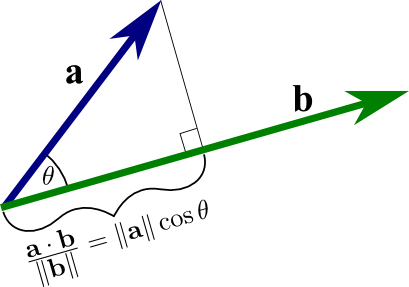

Then dot product
$\mathbf{a}^T\mathbf{b}$ is defined as follows:

$$\mathbf{a}^T\mathbf{b} = |\mathbf{a}|.|\mathbf{b}|.cos(\theta)$$

One important use of dot products is in **projections**. The scalar projection of $\mathbf{a}$ onto $\mathbf{b}$ is the length of the segment marked in the figure with a curly line. It represents the distance from the origin of the vector along the direction of of the vector $\mathbf{b}$ to the point where a perpendicular dromped from the tip of vector $\mathbf{a}$ meets the line containing $\mathbf{b}$. We will refer to this distance with the letter $x$ and corresponds to the **projection** of **shadow** of $\mathbf{a}$ onto $\mathbf{b}$.

From the definition of the dot product, we can calculate the **projection** $d$ of $\mathbf{a}$ onto $\mathbf{b}$ (in inversly, the projection of $\mathbf{b}$ onto $\mathbf{a}$, as follows:

First, let's recall that by the definition of the _cosine_ we have $cos(\theta) = x/|\mathbf{a}|$. Then, using the definition of the dot-product, we have the following:

$$\mathbf{a}^T\mathbf{b} = |\mathbf{a}|.|\mathbf{b}|.cos(\theta)$$

by dividing both sides by $|\mathbf{b}|$

$$\frac{\mathbf{a}^T\mathbf{b}}{|\mathbf{b}|} = |\mathbf{a}|.cos(\theta)$$

Substituting the definition of the cosine that involves the projection $x$, we have the following:

$$\frac{\mathbf{a}^T\mathbf{b}}{|\mathbf{b}|} = |\mathbf{a}|.\frac{x}{|\mathbf{a}|} $$

Therefore, the scalar projection $x$ (i.e. the length if the segment) of  $\mathbf{a}$ onto $\mathbf{b} is given by:

$$ x = \frac{\mathbf{a}^T\mathbf{b}}{|\mathbf{b}|}$$

We can obtain the corresponding result for the scalar projection of $\mathbf{b}$ onto $\mathbf{a}$.  







### Using dot-products to Check orthogonality

By the definition of the dot-product

$$\mathbf{a}^T\mathbf{b} = |\mathbf{a}|.|\mathbf{b}|.cos(\theta)$$

we can see that for $\mathbf{a}^T\mathbf{b}=0$ when $cos(\theta)==0$ and we know that    $cos(\theta)==0$ when $\theta =90$ degrees. We can use this property to check if the two vectors are orthogonal (i.e. perpendicular to each other), by calculating their dot-product and checking if it is equal to zero.



## Matrix--Vector Products

Now that we know how to calculate dot products,
we can begin to understand the *product*
between an $m \times n$ matrix $\mathbf{A}$
and an $n$-dimensional vector $\mathbf{x}$.
To start off, we visualize our matrix
in terms of its row vectors

$$\mathbf{A}=
\begin{bmatrix}
\mathbf{a}^\top_{1} \\
\mathbf{a}^\top_{2} \\
\vdots \\
\mathbf{a}^\top_m \\
\end{bmatrix},$$

where each $\mathbf{a}^\top_{i} \in \mathbb{R}^n$
is a row vector representing the $i^\textrm{th}$ row
of the matrix $\mathbf{A}$.

[**The matrix--vector product $\mathbf{A}\mathbf{x}$
is simply a column vector of length $m$,
whose $i^\textrm{th}$ element is the dot product
$\mathbf{a}^\top_i \mathbf{x}$:**]

$$
\mathbf{A}\mathbf{x}
= \begin{bmatrix}
\mathbf{a}^\top_{1} \\
\mathbf{a}^\top_{2} \\
\vdots \\
\mathbf{a}^\top_m \\
\end{bmatrix}\mathbf{x}
= \begin{bmatrix}
 \mathbf{a}^\top_{1} \mathbf{x}  \\
 \mathbf{a}^\top_{2} \mathbf{x} \\
\vdots\\
 \mathbf{a}^\top_{m} \mathbf{x}\\
\end{bmatrix}.
$$

We can think of multiplication with a matrix
$\mathbf{A}\in \mathbb{R}^{m \times n}$
as a transformation that projects vectors
from $\mathbb{R}^{n}$ to $\mathbb{R}^{m}$.
These transformations are remarkably useful.
For example, we can represent rotations
as multiplications by certain square matrices.
Matrix--vector products also describe
the key calculation involved in computing
the outputs of each layer in a neural network
given the outputs from the previous layer.


To express a matrix--vector product in code,
we use the `mv` function.
Note that the column dimension of `A`
(its length along axis 1)
must be the same as the dimension of `x` (its length).
Python has a convenience operator `@`
that can execute both matrix--vector
and matrix--matrix products
(depending on its arguments).
Thus we can write `A@x`.


In [ ]:
# Notice A is 2x3 while x is 3 x 1 (the inner axis match)
A.shape, x.shape, torch.mv(A, x), A@x

(torch.Size([2, 3]), torch.Size([3]), tensor([17., 53.]), tensor([17., 53.]))

## Matrix--Matrix Multiplication

Once you have gotten the hang of dot products and matrix--vector products,
then *matrix--matrix multiplication* should be straightforward.

Say that we have two matrices
$\mathbf{A} \in \mathbb{R}^{n \times k}$
and $\mathbf{B} \in \mathbb{R}^{k \times m}$:

$$\mathbf{A}=\begin{bmatrix}
 a_{11} & a_{12} & \cdots & a_{1k} \\
 a_{21} & a_{22} & \cdots & a_{2k} \\
\vdots & \vdots & \ddots & \vdots \\
 a_{n1} & a_{n2} & \cdots & a_{nk} \\
\end{bmatrix},\quad
\mathbf{B}=\begin{bmatrix}
 b_{11} & b_{12} & \cdots & b_{1m} \\
 b_{21} & b_{22} & \cdots & b_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
 b_{k1} & b_{k2} & \cdots & b_{km} \\
\end{bmatrix}.$$


Let $\mathbf{a}^\top_{i} \in \mathbb{R}^k$ denote
the row vector representing the $i^\textrm{th}$ row
of the matrix $\mathbf{A}$
and let $\mathbf{b}_{j} \in \mathbb{R}^k$ denote
the column vector from the $j^\textrm{th}$ column
of the matrix $\mathbf{B}$:

$$\mathbf{A}=
\begin{bmatrix}
\mathbf{a}^\top_{1} \\
\mathbf{a}^\top_{2} \\
\vdots \\
\mathbf{a}^\top_n \\
\end{bmatrix},
\quad \mathbf{B}=\begin{bmatrix}
 \mathbf{b}_{1} & \mathbf{b}_{2} & \cdots & \mathbf{b}_{m} \\
\end{bmatrix}.
$$


To form the matrix product $\mathbf{C} \in \mathbb{R}^{n \times m}$,
we simply compute each element $c_{ij}$
as the dot product between
the $i^{\textrm{th}}$ row of $\mathbf{A}$
and the $j^{\textrm{th}}$ column of $\mathbf{B}$,
i.e., $\mathbf{a}^\top_i \mathbf{b}_j$:

$$\mathbf{C} = \mathbf{AB} = \begin{bmatrix}
\mathbf{a}^\top_{1} \\
\mathbf{a}^\top_{2} \\
\vdots \\
\mathbf{a}^\top_n \\
\end{bmatrix}
\begin{bmatrix}
 \mathbf{b}_{1} & \mathbf{b}_{2} & \cdots & \mathbf{b}_{m} \\
\end{bmatrix}
= \begin{bmatrix}
\mathbf{a}^\top_{1} \mathbf{b}_1 & \mathbf{a}^\top_{1}\mathbf{b}_2& \cdots & \mathbf{a}^\top_{1} \mathbf{b}_m \\
 \mathbf{a}^\top_{2}\mathbf{b}_1 & \mathbf{a}^\top_{2} \mathbf{b}_2 & \cdots & \mathbf{a}^\top_{2} \mathbf{b}_m \\
 \vdots & \vdots & \ddots &\vdots\\
\mathbf{a}^\top_{n} \mathbf{b}_1 & \mathbf{a}^\top_{n}\mathbf{b}_2& \cdots& \mathbf{a}^\top_{n} \mathbf{b}_m
\end{bmatrix}.
$$

[**We can think of the matrix--matrix multiplication $\mathbf{AB}$
as performing $m$ matrix--vector products
or $m \times n$ dot products
and stitching the results together
to form an $n \times m$ matrix.**]
In the following snippet,
we perform matrix multiplication on `A` and `B`.
Here, `A` is a matrix with two rows and three columns,
and `B` is a matrix with three rows and four columns.
After multiplication, we obtain a matrix with two rows and four columns.


In [ ]:
B = torch.ones(3, 4)
torch.mm(A, B), A@B

(tensor([[ 3.,  3.,  3.,  3.],
         [12., 12., 12., 12.]]),
 tensor([[ 3.,  3.,  3.,  3.],
         [12., 12., 12., 12.]]))

The term *matrix--matrix multiplication* is
often simplified to *matrix multiplication*,
and should not be confused with the Hadamard product.


## Norms

Some of the most useful operators in linear algebra are *norms*.
Informally, the norm of a vector tells us how *big* it is.
For instance, the $\ell_2$ norm measures
the (Euclidean) length of a vector.
Here, we are employing a notion of *size* that concerns the magnitude of a vector's components
(not its dimensionality).

A norm is a function $\| \cdot \|$ that maps a vector
to a scalar and satisfies the following three properties:

1. Given any vector $\mathbf{x}$, if we scale (all elements of) the vector
   by a scalar $\alpha \in \mathbb{R}$, its norm scales accordingly:
   $$\|\alpha \mathbf{x}\| = |\alpha| \|\mathbf{x}\|.$$
2. For any vectors $\mathbf{x}$ and $\mathbf{y}$:
   norms satisfy the triangle inequality:
   $$\|\mathbf{x} + \mathbf{y}\| \leq \|\mathbf{x}\| + \|\mathbf{y}\|.$$
3. The norm of a vector is nonnegative and it only vanishes if the vector is zero:
   $$\|\mathbf{x}\| > 0 \textrm{ for all } \mathbf{x} \neq 0.$$

Many functions are valid norms and different norms
encode different notions of size.
The Euclidean norm that we all learned in elementary school geometry
when calculating the hypotenuse of a right triangle
is the square root of the sum of squares of a vector's elements.
Formally, this is called [**the $\ell_2$ *norm***] and expressed as

$$ \|\mathbf{x}\|_2 = \sqrt{ \sum_{i=1}^{n} x_i^2} = SQRT(\sum_{i=1}^{n} x_i^2) =$$

$$ \|\mathbf{x}\|_2 = \sqrt{x^Tx} $$

The method `norm` calculates the $\ell_2$ norm.


In [ ]:
u = torch.tensor([3.0, -4.0])
torch.norm(u)

tensor(5.)

**Achnowledgement** : The materials presented here are adaptations from the  Zhang, Aston, and Lipton, Zachary C., and Li, Mu, and Smola, Alexander J. Book "Dive into Deep Learning."